<a href="https://colab.research.google.com/github/BagusWichaksono/MachineLearning_2026/blob/main/Jobsheet04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Jobsheet 04: Klasterisasi (Clustering) - Machine Learning

# Praktikum 1: K-Means Clustering

> **Download dataset `Iris.csv` terlebih dahulu**

### KMeans

KMeans adalah satu metode unsupervised learning pada machine learning. Metode ini menentukan jumlah cluster sesuai dengan jumlah $k$ yang dipilih. Proses KMeans secara manual, dapat dilihat pada [Perhitungan Manual KMeans](https://colab.research.google.com/corgiredirector?site=https%3A%2F%2Fdocs.google.com%2Fspreadsheets%2Fd%2F16C2HxTFicQ5tS7aXc1Uvlu1kyvk20LSA_P-E2p47kLY%2Fedit%3Fusp%3Dsharing).

Pada modul jobsheet ini, kita akan langsung mempraktikkan pembuatan model KMeans dengan menggunakan python pada dataset iris.

--- Data Head ---
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

--- Data Fitur (X) ---
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2


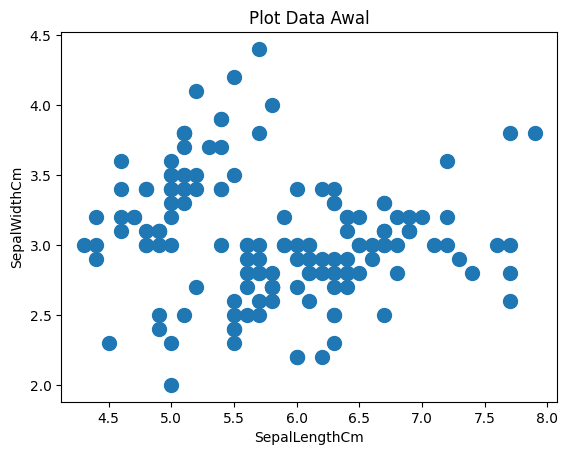

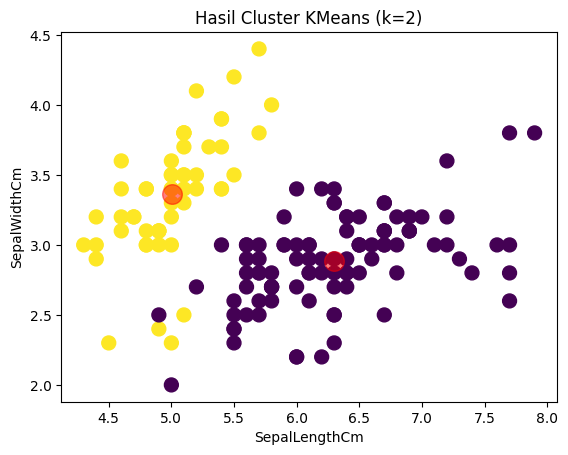

Nilai SSE: 152.36870647733915



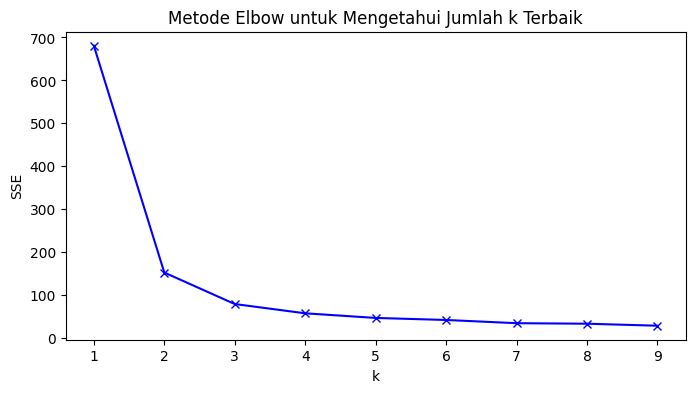

--- Nilai SSE Setiap Nilai k ---
k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94084142614601
k=4; SSE=57.34540931571815
k=5; SSE=46.56163015873017
k=6; SSE=41.801410101010106
k=7; SSE=34.31265004600874
k=8; SSE=33.08871865715982
k=9; SSE=28.415083024865638


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Persiapan data
df = pd.read_csv('Iris.csv')

print("--- Data Head ---")
print(df.head())

# 2. Seleksi Fitur
X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

print("\n--- Data Fitur (X) ---")
print(X.head())

# 3. Plot Data Awal (Sepal Length & Sepal Width)
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)
plt.xlabel("SepalLengthCm")
plt.ylabel("SepalWidthCm")
plt.title("Plot Data Awal")
plt.show()

# 4. Buat Model KMeans (k=2)
cl_kmeans = KMeans(n_clusters=2)
y_kmeans = cl_kmeans.fit_predict(X)

# 5. Plot Hasil Cluster & Centroid
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)
plt.xlabel("SepalLengthCm")
plt.ylabel("SepalWidthCm")
plt.title("Hasil Cluster KMeans (k=2)")
plt.show()

# 6. Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}\n')

# 7. Implementasi Metode Elbow
sse = []
K = range(1, 10)

for k in K:
    kmeanModel = KMeans(n_clusters=k)
    kmeanModel.fit(X)
    sse.append(kmeanModel.inertia_)

# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

# 8. Cek Nilai SSE setiap k
print("--- Nilai SSE Setiap Nilai k ---")
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

# Praktikum 2: Pengantar k-Means & Algoritma Expectation-Maximization

Pada praktikum ini, kita akan mempelajari konsep k-Means melalui algoritma Expectation-Maximization (EM), menganalisis batasan k-Means pada data non-linier, serta menerapkannya pada dua kasus nyata:
1. Klasifikasi Karakter Angka (MNIST Digits)
2. Kompresi Citra (Reduksi Warna Gambar)

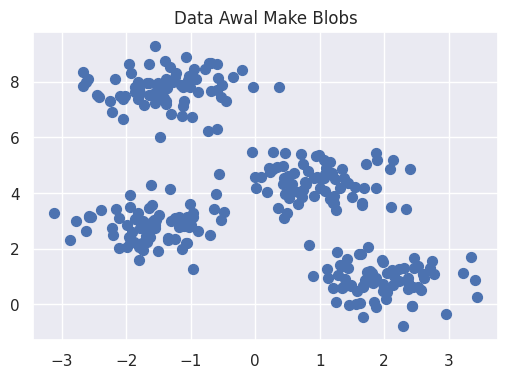

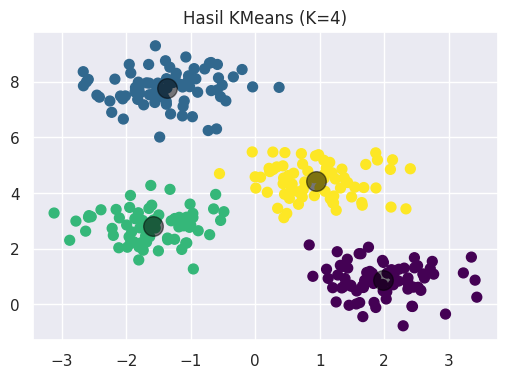

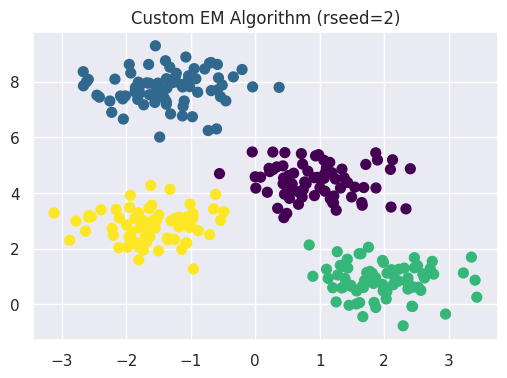

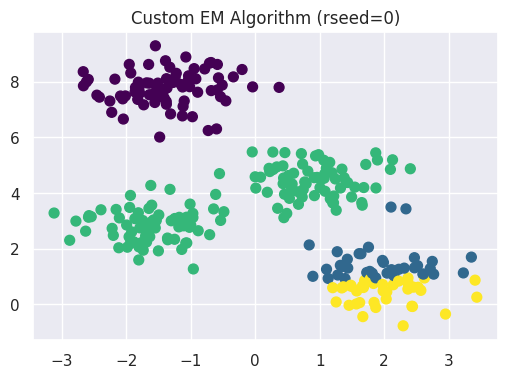

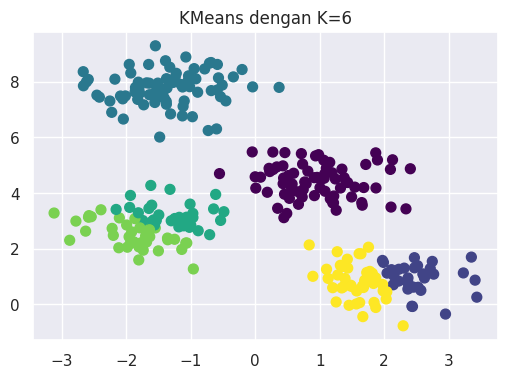

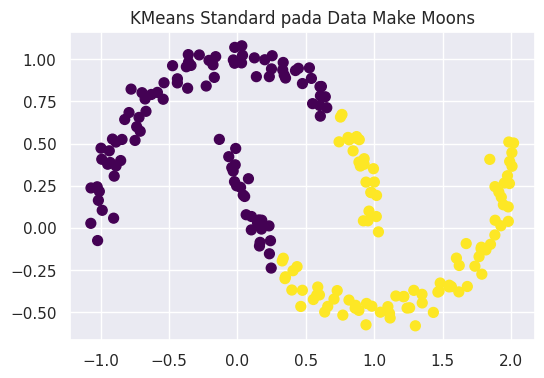

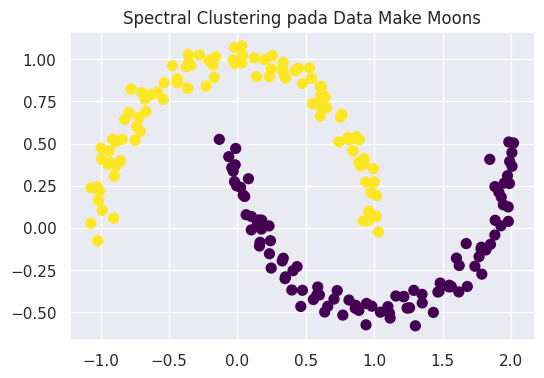

Bentuk data Digits: (1797, 64)


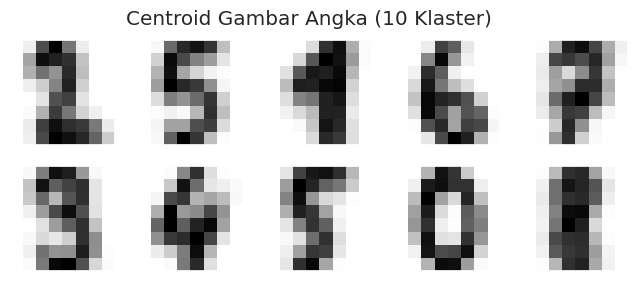

Akurasi KMeans Dasar: 0.7440


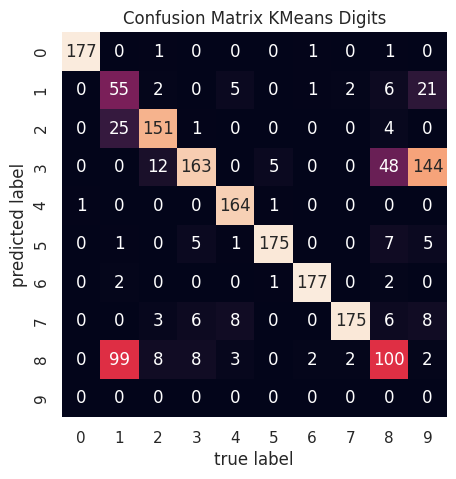

Akurasi KMeans setelah t-SNE: 0.9410


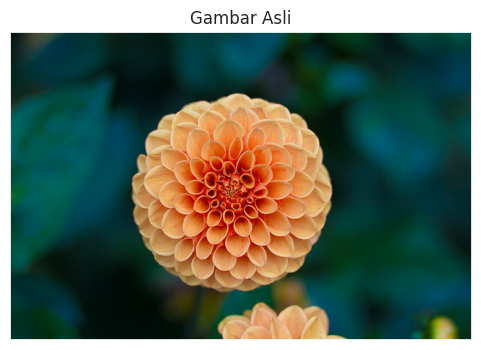

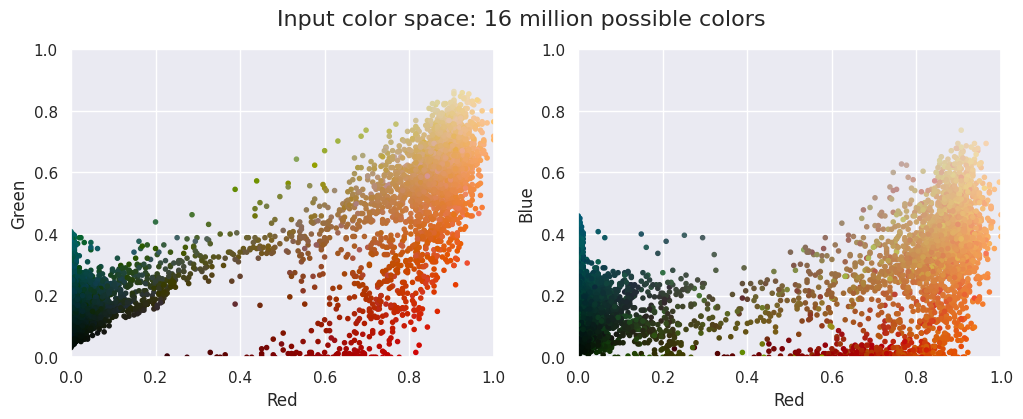

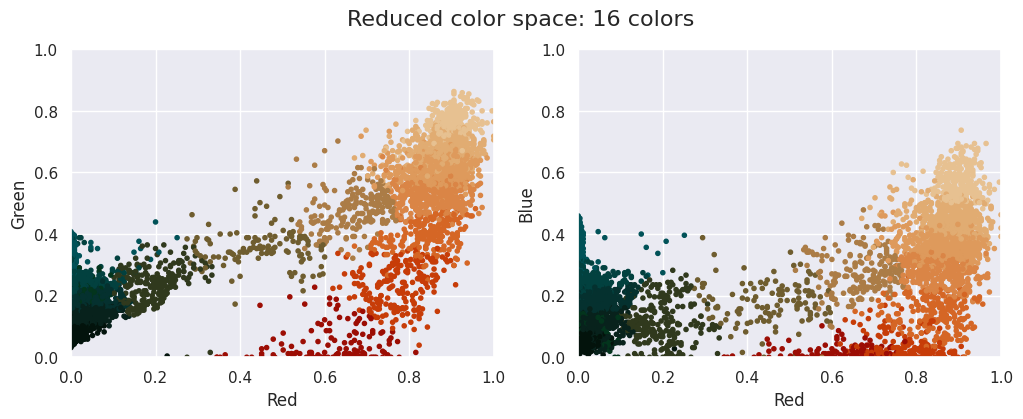

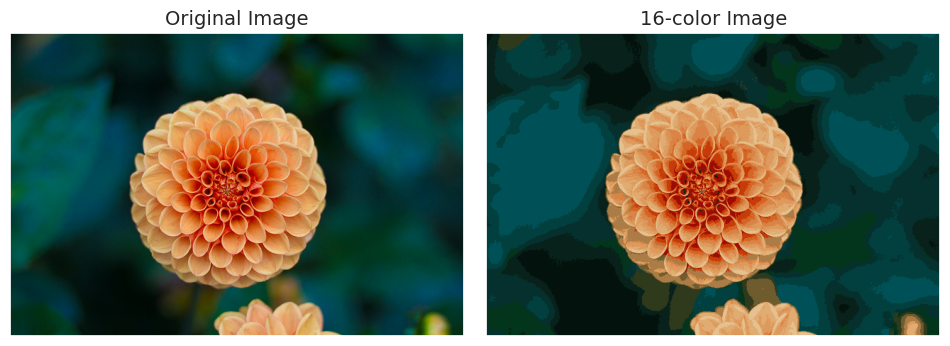

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.datasets import make_blobs, make_moons, load_digits, load_sample_image
from sklearn.cluster import KMeans, SpectralClustering, MiniBatchKMeans
from sklearn.metrics import pairwise_distances_argmin, accuracy_score, confusion_matrix
from sklearn.manifold import TSNE
from scipy.stats import mode
import warnings; warnings.simplefilter('ignore')

# 1. Pengantar k-Means dengan Make Blobs
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Data Awal Make Blobs")
plt.show()

kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)
plt.title("Hasil KMeans (K=4)")
plt.show()

# 2. Algoritma Custom Expectation-Maximization (EM)
def find_clusters(X, n_clusters, rseed=2):
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        labels = pairwise_distances_argmin(X, centers)
        new_centers = np.array([X[labels == i].mean(0) for i in range(n_clusters)])
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.title("Custom EM Algorithm (rseed=2)")
plt.show()

centers, labels = find_clusters(X, 4, rseed=0)
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.title("Custom EM Algorithm (rseed=0)")
plt.show()

labels = KMeans(6, random_state=0).fit_predict(X)
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis')
plt.title("KMeans dengan K=6")
plt.show()

# 3. Batas Klaster Non-Linier (Make Moons & Spectral Clustering)
X_moon, y_moon = make_moons(200, noise=.05, random_state=0)

labels = KMeans(2, random_state=0).fit_predict(X_moon)
plt.figure(figsize=(6, 4))
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=labels, s=50, cmap='viridis')
plt.title("KMeans Standard pada Data Make Moons")
plt.show()

model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', assign_labels='kmeans')
labels = model.fit_predict(X_moon)
plt.figure(figsize=(6, 4))
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=labels, s=50, cmap='viridis')
plt.title("Spectral Clustering pada Data Make Moons")
plt.show()

# 4. Studi Kasus 1: Digits Dataset
digits = load_digits()
print(f"Bentuk data Digits: {digits.data.shape}")

kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)

fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)
plt.suptitle("Centroid Gambar Angka (10 Klaster)")
plt.show()

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

print(f"Akurasi KMeans Dasar: {accuracy_score(digits.target, labels):.4f}")

plt.figure(figsize=(6, 5))
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label')
plt.title("Confusion Matrix KMeans Digits")
plt.show()

tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

print(f"Akurasi KMeans setelah t-SNE: {accuracy_score(digits.target, labels):.4f}")

# 5. Studi Kasus 2: Kompresi Citra
flower = load_sample_image("flower.jpg")

plt.figure(figsize=(6, 4))
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower)
plt.title("Gambar Asli")
plt.show()

data = flower / 255.0
data = data.reshape(427 * 640, 3)

def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=16)

plot_pixels(data, title='Input color space: 16 million possible colors')
plt.show()

kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors, title="Reduced color space: 16 colors")
plt.show()

flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 5), subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=14)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=14)
plt.show()

# Praktikum 3: DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

Pada praktikum ini, kita akan mempraktikkan algoritma **DBSCAN** pada dataset sintetis buatan `make_blobs`:
1. Membuat dan memvisualisasikan dataset sintetis berskala standar.
2. Mengukur dan menghitung DBSCAN (`eps=0.3`, `min_samples=10`).
3. Evaluasi metrik performa klasterisasi (*Homogeneity, Completeness, Silhouette Coefficient*, dll).
4. Visualisasi hasil pengelompokan yang membedakan **Core Samples**, **Non-Core Samples**, dan **Noise/Outlier**.

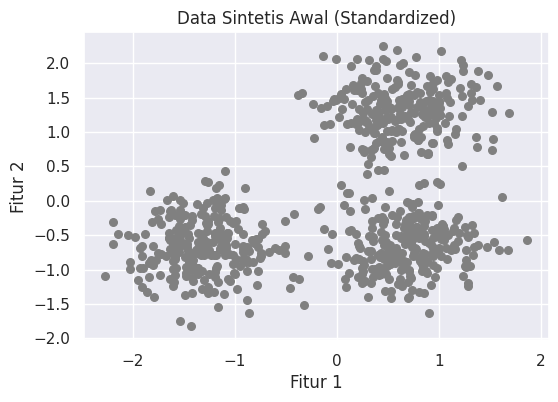

Estimated number of clusters: 3
Estimated number of noise points: 18

--- Evaluasi Metrik DBSCAN ---
Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


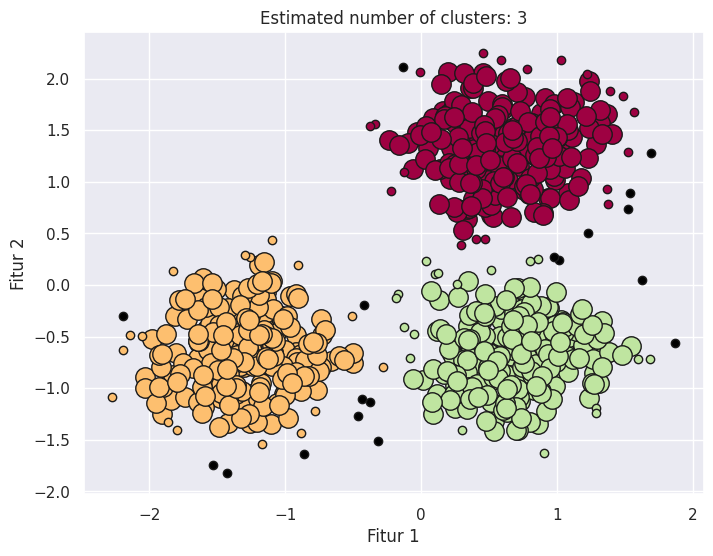

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

# 1. Pembuatan Dataset Sintetis
centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], s=30, color='gray')
plt.title("Data Sintetis Awal (Standardized)")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.show()

# 2. Compute DBSCAN
db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

# 3. Evaluasi Kualitas Klasterisasi
print("\n--- Evaluasi Metrik DBSCAN ---")
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(f"Adjusted Mutual Information: {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}")
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

# 4. Visualisasi Hasil Klasterisasi
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(8, 6))
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.show()

# Tugas Praktikum Jobsheet 04: Klasterisasi

**1. Tugas K-Means (Segmentasi Pelanggan)**
* Memuat dataset `Mall_Customers.csv`.
* Memilih fitur `Annual Income (k$)` dan `Spending Score (1-100)`.
* Menentukan $k$ terbaik menggunakan Elbow Method (WCSS) & Silhouette Score, kemudian memvisualisasikan hasil cluster dan centroids.

**2. Tugas DBSCAN (Eksperimen Parametrik pada Dataset Make Moons)**
* Memuat dataset `make_moons` (1000 sampel, noise=0.05) dan melakukan standardisasi.
* Mengenang DBSCAN baseline (`eps=0.2`, `min_samples=5`) dan mengevaluasi seluruh metrik performa.
* Menguji eksperimen kombinasi parameter `eps` (0.05, 0.1, 0.3, 0.5) dan `min_samples` (3, 10, 20) serta memvisualisasikannya.

--- TUGAS 1: K-MEANS CLUSTERING ---
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


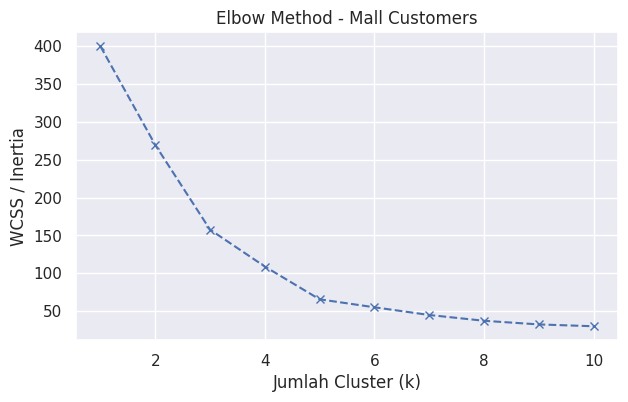


--- Silhouette Score per Nilai k ---
Jumlah k = 2 | Silhouette Score: 0.3213
Jumlah k = 3 | Silhouette Score: 0.4666
Jumlah k = 4 | Silhouette Score: 0.4939
Jumlah k = 5 | Silhouette Score: 0.5547
Jumlah k = 6 | Silhouette Score: 0.5399


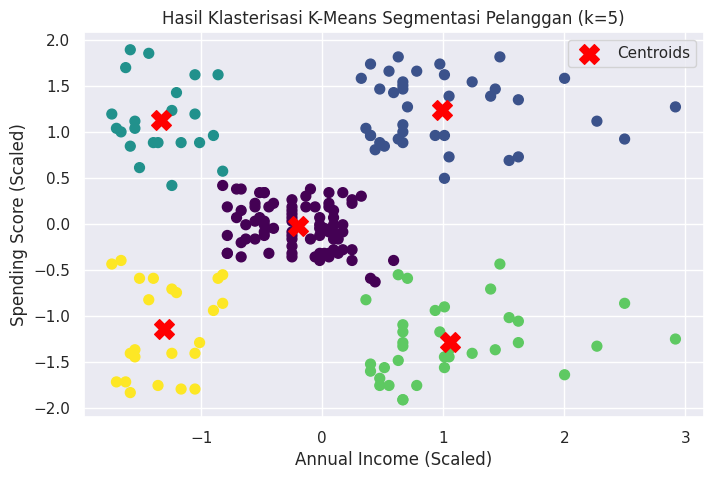


--- TUGAS 2: DBSCAN EXPERIMENT ---
Jumlah Cluster Baseline : 2
Jumlah Noise Baseline   : 0

--- Metrik Evaluasi Baseline ---
Homogeneity                : 1.0000
Completeness               : 1.0000
V-measure                  : 1.0000
Adjusted Rand Index (ARI)  : 1.0000
Adjusted Mutual Info (AMI) : 1.0000
Silhouette Coefficient     : 0.3912


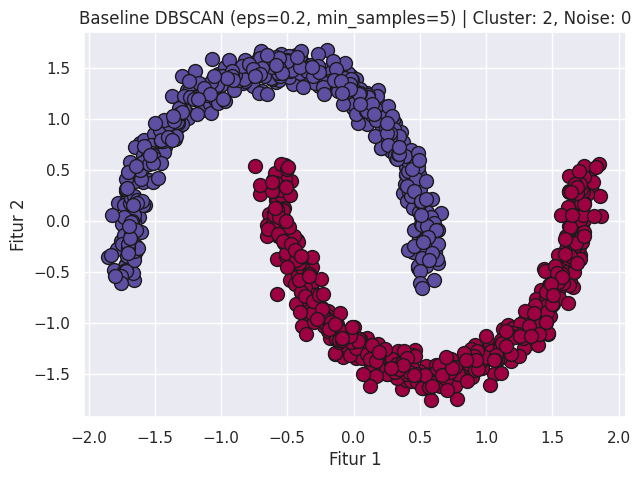


--- HASIL EKSPERIMEN PARAMETRIK DBSCAN ---
 eps  min_samples  Clusters  Noise     ARI V-Measure Silhouette
0.05            3        69    186    0.03     0.257     0.1129
0.05           10         3    970  0.0023    0.0494    -0.2942
0.05           20         0   1000     N/A       N/A        N/A
0.10            3         2     14  0.9722    0.9427     0.2517
0.10           10         7     57  0.5234    0.5711     0.1623
0.10           20         6    850  0.0168    0.1547    -0.3602
0.30            3         2      0     1.0       1.0     0.3912
0.30           10         2      0     1.0       1.0     0.3912
0.30           20         2      0     1.0       1.0     0.3912
0.50            3         2      0     1.0       1.0     0.3912
0.50           10         2      0     1.0       1.0     0.3912
0.50           20         2      0     1.0       1.0     0.3912


In [ ]:
# --------------------------------------------------
# TUGAS 1: K-MEANS CLUSTERING (MALL CUSTOMERS)
# --------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print("--- TUGAS 1: K-MEANS CLUSTERING ---")

url_mall = "https://raw.githubusercontent.com/SteffiPeT/Machine-Learning-Datasets/main/Mall_Customers.csv"
try:
    df_mall = pd.read_csv('Mall_Customers.csv')
except:
    df_mall = pd.read_csv(url_mall)

print(df_mall.head())

X_mall = df_mall.iloc[:, [3, 4]].values

scaler = StandardScaler()
X_mall_scaled = scaler.fit_transform(X_mall)

wcss_mall = []
K_mall = range(1, 11)
for k in K_mall:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_mall_scaled)
    wcss_mall.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_mall, wcss_mall, 'bx--')
plt.title("Elbow Method - Mall Customers")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("WCSS / Inertia")
plt.grid(True)
plt.show()

print("\n--- Silhouette Score per Nilai k ---")
for k in range(2, 7):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    lbls = km.fit_predict(X_mall_scaled)
    sc = silhouette_score(X_mall_scaled, lbls)
    print(f"Jumlah k = {k} | Silhouette Score: {sc:.4f}")

k_opt = 5
kmeans_mall = KMeans(n_clusters=k_opt, init='k-means++', n_init=10, random_state=42)
df_mall['Cluster'] = kmeans_mall.fit_predict(X_mall_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_mall_scaled[:, 0], X_mall_scaled[:, 1], c=df_mall['Cluster'], cmap='viridis', s=50)

centers_mall = kmeans_mall.cluster_centers_
plt.scatter(centers_mall[:, 0], centers_mall[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title(f"Hasil Klasterisasi K-Means Segmentasi Pelanggan (k={k_opt})")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------
# TUGAS 2: DBSCAN EXPERIMENT (MAKE MOONS)
# --------------------------------------------------
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn import metrics

print("\n--- TUGAS 2: DBSCAN EXPERIMENT ---")

X_moons, y_true_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)
X_moons_scaled = StandardScaler().fit_transform(X_moons)

db_base = DBSCAN(eps=0.2, min_samples=5).fit(X_moons_scaled)
labels_base = db_base.labels_

n_clusters_base = len(set(labels_base)) - (1 if -1 in labels_base else 0)
n_noise_base = list(labels_base).count(-1)

print(f"Jumlah Cluster Baseline : {n_clusters_base}")
print(f"Jumlah Noise Baseline   : {n_noise_base}")

print("\n--- Metrik Evaluasi Baseline ---")
print(f"Homogeneity                : {metrics.homogeneity_score(y_true_moons, labels_base):.4f}")
print(f"Completeness               : {metrics.completeness_score(y_true_moons, labels_base):.4f}")
print(f"V-measure                  : {metrics.v_measure_score(y_true_moons, labels_base):.4f}")
print(f"Adjusted Rand Index (ARI)  : {metrics.adjusted_rand_score(y_true_moons, labels_base):.4f}")
print(f"Adjusted Mutual Info (AMI) : {metrics.adjusted_mutual_info_score(y_true_moons, labels_base):.4f}")
print(f"Silhouette Coefficient     : {metrics.silhouette_score(X_moons_scaled, labels_base):.4f}")

def plot_dbscan(X_data, labels_data, db_model, title_str):
    unique_lbls = set(labels_data)
    core_mask = np.zeros_like(labels_data, dtype=bool)
    core_mask[db_model.core_sample_indices_] = True

    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_lbls))]

    plt.figure(figsize=(7, 5))
    for k, col in zip(unique_lbls, colors):
        if k == -1:
            col = [0, 0, 0, 1]

        class_mask = (labels_data == k)

        xy_core = X_data[class_mask & core_mask]
        plt.plot(xy_core[:, 0], xy_core[:, 1], 'o', markerfacecolor=tuple(col),
                 markeredgecolor='k', markersize=10)

        xy_non_core = X_data[class_mask & ~core_mask]
        plt.plot(xy_non_core[:, 0], xy_non_core[:, 1], 'o', markerfacecolor=tuple(col),
                 markeredgecolor='k', markersize=4)

    plt.title(title_str)
    plt.xlabel("Fitur 1")
    plt.ylabel("Fitur 2")
    plt.show()

plot_dbscan(X_moons_scaled, labels_base, db_base, f"Baseline DBSCAN (eps=0.2, min_samples=5) | Cluster: {n_clusters_base}, Noise: {n_noise_base}")

eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

print("\n--- HASIL EKSPERIMEN PARAMETRIK DBSCAN ---")

results = []
for eps in eps_values:
    for ms in min_samples_values:
        db_exp = DBSCAN(eps=eps, min_samples=ms).fit(X_moons_scaled)
        lbls_exp = db_exp.labels_

        n_c = len(set(lbls_exp)) - (1 if -1 in lbls_exp else 0)
        n_n = list(lbls_exp).count(-1)

        if n_c > 1:
            sil = metrics.silhouette_score(X_moons_scaled, lbls_exp)
            ari = metrics.adjusted_rand_score(y_true_moons, lbls_exp)
            v_m = metrics.v_measure_score(y_true_moons, lbls_exp)
        else:
            sil = np.nan
            ari = np.nan
            v_m = np.nan

        results.append({
            'eps': eps,
            'min_samples': ms,
            'Clusters': n_c,
            'Noise': n_n,
            'ARI': round(ari, 4) if not np.isnan(ari) else 'N/A',
            'V-Measure': round(v_m, 4) if not np.isnan(v_m) else 'N/A',
            'Silhouette': round(sil, 4) if not np.isnan(sil) else 'N/A'
        })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))